# Study CAX M1 misalignment effects on the X-ray beam

```2026/07/10```

In [1]:
import os
import sys

sys.path.append(os.path.expanduser("~/repos/cax-scripts"))
# sys.path.append(os.path.expanduser("~/repos/cax-control"))

from shadowpy.cax_simulation import CAXSim
import numpy as np
import matplotlib.pyplot as plt

In [13]:
cax = CAXSim(total_rays=500000)


 Generated        25000  rays out of       500000
                  50000
                  75000
                 100000
                 125000
                 150000
                 175000
                 200000
                 225000
                 250000
                 275000
                 300000
                 325000
                 350000
                 375000
                 400000
                 425000
                 450000
                 475000
                 500000
 Exit from SOURCE


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 2: DVF_A1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
Traced through element 3: DVF_B1
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR


In [5]:
def _perform_plot_caustic(cax: CAXSim):
    dist, fwhm_x, fwhm_y = \
        cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam,
                                    (-250, 250),
                                    n_points=100, 
                                    max_workers=10)

    astig = dist[np.argmin(fwhm_x)] - dist[np.argmin(fwhm_y)]

    plt.figure(figsize=(12, 6))
    plt.plot(dist, 1000*fwhm_x, marker='o', markersize=5, label="FWHM X")
    plt.plot(dist, 1000*fwhm_y, marker='o', markersize=5, label="FWHM Y")
    plt.vlines(dist[np.argmin(fwhm_x)], 0, 1000*np.min(fwhm_x), color='blue', linestyle='--', label=f"Min FWHM X: {1000*np.min(fwhm_x):.2f} μm at {dist[np.argmin(fwhm_x)]:.2f} mm")
    plt.vlines(dist[np.argmin(fwhm_y)], 0, 1000*np.min(fwhm_y), color='orange', linestyle='--', label=f"Min FWHM Y: {1000*np.min(fwhm_y):.2f} μm at {dist[np.argmin(fwhm_y)]:.2f} mm")
    plt.xlabel('Distance from screen (mm)')
    plt.ylabel('FWHM (μm)')
    plt.title(f'Caustic of the beam: astigmatism of {astig:.2f} mm')
    plt.legend()
    plt.grid()
    plt.show()

    return astig

In [20]:
# cax.mirror.ry = -11.e-4
# cax.mirror.ry
# cax.mirror.tx = 10.e-3
# cax.mirror.rx = 2.e-3

cax.mirror.tx = 0.1
cax.mirror.ry = 0.01

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 1: M1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
Traced through element 2: DVF_A1
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
Traced through element 3: DVF_B1
 Call to RESTART
 Exit from RESTART
 Call to MIRROR


Calculating caustic in parallel...
Caustic calculation completed.


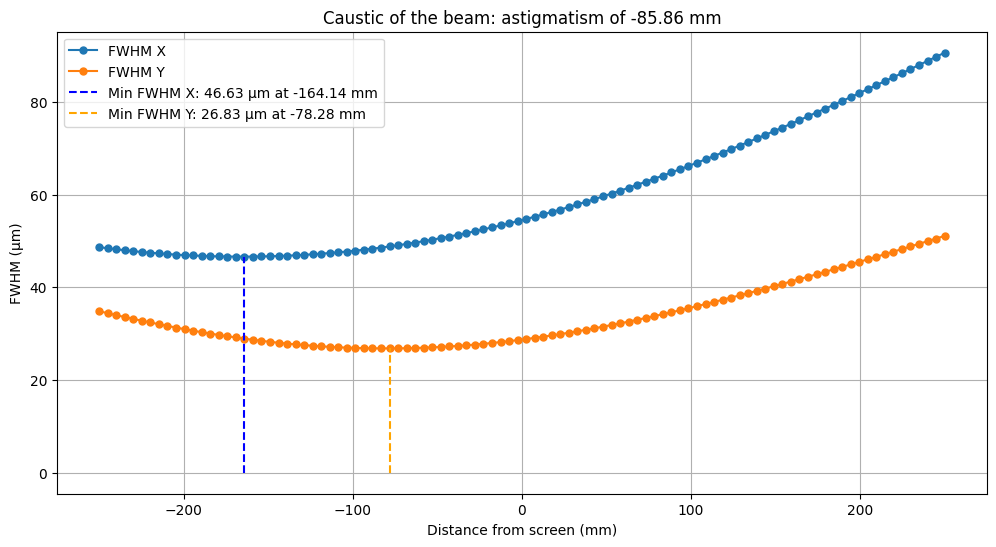

-85.85858585858585

In [11]:
_perform_plot_caustic(cax)

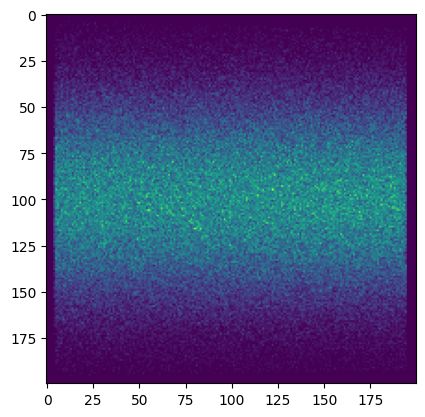

In [21]:
plt.imshow(cax.mirror.image.img.T)

(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

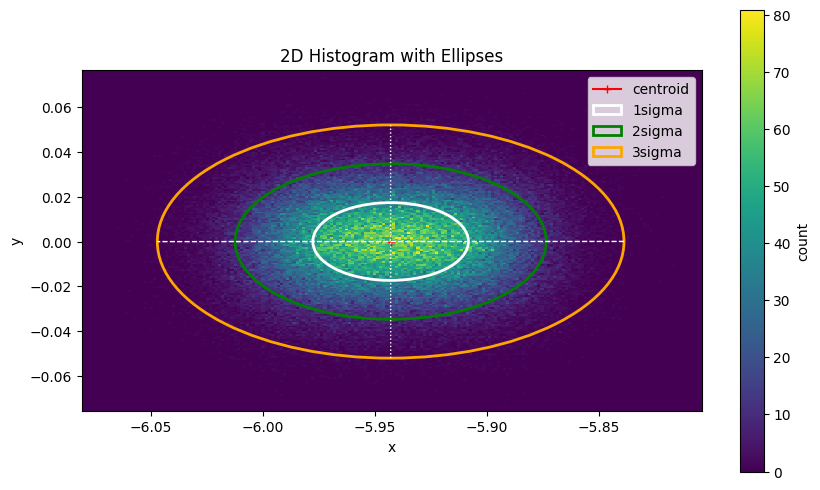

In [22]:
cax.dvf_B1.image.plot()

In [6]:
cax.dvf_B1.image.print_stats(hprm=cax.dvf_B1.image.hprm_fitting)

centroid   = (-1.5454e-04, -1.4648e-04)
sigma x    = 2.2693e-02
sigma y    = 1.2415e-02
fwhm x     = 5.3439e-02
fwhm y     = 2.9235e-02
xy cov     = -6.7869e-09

principal sigmas:
    sigma minor = 0.012414777053100545
    sigma major = 0.022693490224919136

theta = -1.8807e-05 rad = -1.0776e-03 deg

cov matrix:
[[ 5.14994498e-04 -6.78687331e-09]
 [-6.78687331e-09  1.54126689e-04]]


In [52]:
cax.dvf_B1.image.print_stats(hprm=cax.dvf_B1.image.hprm_fitting)

centroid   = (-1.3483e-04, -1.4873e-04)
sigma x    = 2.2732e-02
sigma y    = 1.2388e-02
fwhm x     = 5.3530e-02
fwhm y     = 2.9172e-02
xy cov     = 8.6793e-08

principal sigmas:
    sigma minor = 0.012388388578886016
    sigma major = 0.02273230661818902

theta = 2.3891e-04 rad = 1.3689e-02 deg

cov matrix:
[[5.16757743e-04 8.67933924e-08]
 [8.67933924e-08 1.53472192e-04]]


In [48]:
cax.mirror.tx
np.rad2deg(cax.mirror.rx)

3.490658503988659e-05

In [53]:
cax.mirror.offset

array([ 1.00000000e-02, -2.04502611e-35, -2.88605333e-52])

In [55]:
cax.mirror.rx = 0.1

Traced through element 1: M1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


Traced through element 2: DVF_A1
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 3: DVF_B1


In [59]:
cax.mirror.shadow_oe.Z_ROT

0.0017453292519943296

In [58]:
np.deg2rad(0.1)

0.0017453292519943296

In [57]:
cax.mirror.tilt

array([ 1.74532925e-03,  8.26479900e-36, -7.13373969e-52])

(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

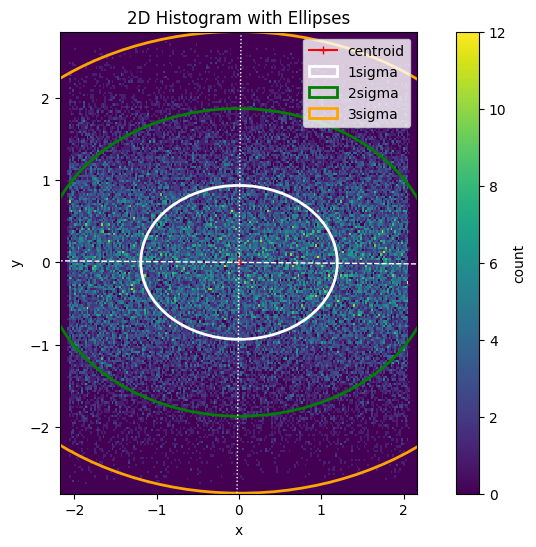

In [39]:
cax.mirror.image.plot()

In [71]:
def CAX_SVD(cax: CAXSim, dT: float = 0.01, dR: float = 0.01):
    """
    Perform SVD analysis on the CAX simulation to determine the sensitivity of the system to misalignments.

    Parameters:
    cax (CAXSim): The CAX simulation object.
    dT (float): The translation step size in mm.
    dR (float): The rotation step size in degrees.

    Returns:
    None
    """
    
    T0 = cax.mirror.offset
    R0 = cax.mirror.tilt

    observables = ['fwhmx', 'fwhmy', 'peak', 'astigmatism']
    knobs = ['tx', 'ty', 'rx', 'ry', 'rz']

    fwhm_x0 = cax.dvf_B1.image.hprm_fitting['fwhmx']
    fwhm_y0 = cax.dvf_B1.image.hprm_fitting['fwhmy']
    peak0 = cax.dvf_B1.image.img.max()

    caustic_offsets = np.linspace(-150, 100, 100)

    dist, fwhm_x, fwhm_y = \
        cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam,
                                    (-250, 250),
                                    n_points=100, 
                                    max_workers=10)

    astigmatism0 = dist[np.argmin(fwhm_x)] - dist[np.argmin(fwhm_y)]

    # Jacobian matrix
    J = np.zeros((len(observables), 5))  # 5 misalignment parameters: tx, ty, rx, ry, rz

    for i, obs in enumerate(observables):
        # Perturb each misalignment parameter and compute the change in the observable
        for j, param in enumerate(knobs):
            # Save original value
            original_value = getattr(cax.mirror, param)

            # Perturb the parameter
            if param in ['tx', 'ty']:
                setattr(cax.mirror, param, original_value + dT)
                delta = dT
            else:
                setattr(cax.mirror, param, np.rad2deg(original_value) + dR)
                delta = dR

            # Compute the observable after perturbation
            if obs == 'fwhmx':
                J[i, j] = (cax.dvf_B1.image.hprm_fitting['fwhmx'] - fwhm_x0)/delta
            elif obs == 'fwhmy':
                J[i, j] = (cax.dvf_B1.image.hprm_fitting['fwhmy'] - fwhm_y0)/delta
            elif obs == 'peak':
                J[i, j] = (cax.dvf_B1.image.img.max() - peak0)/delta
            elif obs == 'astigmatism':
                dist, fwhm_x, fwhm_y = \
                    cax.dvf_B1.parallel_caustic(cax.dvf_B1.beam,
                                    (-250, 250),
                                    n_points=100, 
                                    max_workers=10)

                astig = dist[np.argmin(fwhm_x)] - dist[np.argmin(fwhm_y)]
                J[i, j] = (astig - astigmatism0)/delta
            # Restore original value
            setattr(cax.mirror, param, original_value)

    print(f"Jacobian matrix: {J}")

    U, S, Vt = np.linalg.svd(J, full_matrices=False)

    return J, U, S, Vt


In [89]:
cax = CAXSim(total_rays=500000)

 Generated        25000  rays out of       500000
                  50000
                  75000
                 100000
                 125000
                 150000
                 175000
                 200000
                 225000
                 250000
                 275000
                 300000
                 325000
                 350000
                 375000
                 400000
                 425000
                 450000
                 475000
                 500000
 Exit from SOURCE


/home/amici/repos/cax-scripts/caxscripts/image_statistics.py:120: UserWarning: Beam not visible; skipping quick analysis.
  self.parameters_from_projections()


 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
Traced through element 1: M1
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
Traced through element 2: DVF_A1
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element 

In [90]:
J, U, S, Vt = CAX_SVD(cax, dT=0.01, dR=0.01)

Calculating caustic in parallel...
Caustic calculation completed.
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
Traced through element 1: M1
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
Traced through element 2: DVF_A1
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 MIRROR1: Warning: Empty element (no mirr.xx file)
 Call to SCREEN
 Exit from SCREEN
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC
 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 E

In [91]:
# jacobian

for i, obs in enumerate(['fwhmx', 'fwhmy', 'peak', 'astigmatism']):
    print(f"Observable: {obs}")
    for j, param in enumerate(['tx', 'ty', 'rx', 'ry', 'rz']):
        print(f"  Sensitivity to {param}: {J[i, j]:.4f}")

Observable: fwhmx
  Sensitivity to tx: 0.0100
  Sensitivity to ty: -0.0000
  Sensitivity to rx: 1.4780
  Sensitivity to ry: 3.2011
  Sensitivity to rz: 0.0008
Observable: fwhmy
  Sensitivity to tx: -0.0059
  Sensitivity to ty: 0.0001
  Sensitivity to rx: 3.7572
  Sensitivity to ry: 1.0386
  Sensitivity to rz: 0.0025
Observable: peak
  Sensitivity to tx: 100.0000
  Sensitivity to ty: 100.0000
  Sensitivity to rx: -3500.0000
  Sensitivity to ry: -5100.0000
  Sensitivity to rz: 700.0000
Observable: astigmatism
  Sensitivity to tx: -505.0505
  Sensitivity to ty: 0.0000
  Sensitivity to rx: 1515.1515
  Sensitivity to ry: -42424.2424
  Sensitivity to rz: -505.0505


In [92]:
# Mode 0:

print(f"Singular value associated with mode 0: {S[0]}")

print(f"Combination of knobs to turn: {np.round(Vt[0], 3)}")
print("*Order of knobs: tx, ty, rx, ry, rz")

print(f"Observable effect by exciting mode 0: {np.round(U.T[0], 3)}")
print("*Order of observables: fwhm_x, fwhm_y, peak, astigmatism")

print("=="*40)
print("Conclusion: turning RY has a strong, isolated effect on astigmatism")
print("=="*40)


# Mode 1:

print(f"Singular value associated with mode 1: {S[1]}")

print(f"Combination of knobs to turn: {np.round(Vt[1], 3)}")
print("*Order of knobs: tx, ty, rx, ry, rz")

print(f"Observable effect by exciting mode 1: {np.round(U.T[1], 3)}")
print("*Order of observables: fwhm_x, fwhm_y, peak, astigmatism")

print("=="*40)
print("Conclusion: turning RX decreases the measured peak")
print("=="*40)


# Mode 2:

print(f"Singular value associated with mode 2: {S[2]}")

print(f"Combination of knobs to turn: {np.round(Vt[2], 3)}")
print("*Order of knobs: tx, ty, rx, ry, rz")

print(f"Observable effect by exciting mode 2: {np.round(U.T[2], 3)}")
print("*Order of observables: fwhm_x, fwhm_y, peak, astigmatism")

print("=="*40)
# print("Conclusion: turning RY has a strong, isolated effect on astigmatism")
print("=="*40)

# Mode 0:

print(f"Singular value associated with mode 3: {S[3]}")

print(f"Combination of knobs to turn: {np.round(Vt[3], 3)}")
print("*Order of knobs: tx, ty, rx, ry, rz")

print(f"Observable effect by exciting mode 3: {np.round(U.T[3], 3)}")
print("*Order of observables: fwhm_x, fwhm_y, peak, astigmatism")

print("=="*40)
print("Conclusion: turning RY has a strong, isolated effect on astigmatism")
print("=="*40)









Singular value associated with mode 0: 42748.472551839026
Combination of knobs to turn: [-0.011  0.     0.026 -1.    -0.01 ]
*Order of knobs: tx, ty, rx, ry, rz
Observable effect by exciting mode 0: [-0.    -0.     0.117  0.993]
*Order of observables: fwhm_x, fwhm_y, peak, astigmatism
Conclusion: turning RY has a strong, isolated effect on astigmatism
Singular value associated with mode 1: 3736.348863874008
Combination of knobs to turn: [ 0.042  0.027 -0.978 -0.028  0.202]
*Order of knobs: tx, ty, rx, ry, rz
Observable effect by exciting mode 1: [-0.    -0.001  0.993 -0.117]
*Order of observables: fwhm_x, fwhm_y, peak, astigmatism
Conclusion: turning RX decreases the measured peak
Singular value associated with mode 2: 0.8298420078167187
Combination of knobs to turn: [ 0.175  0.129  0.208 -0.006  0.954]
*Order of knobs: tx, ty, rx, ry, rz
Observable effect by exciting mode 2: [ 0.351  0.937  0.001 -0.   ]
*Order of observables: fwhm_x, fwhm_y, peak, astigmatism
Singular value associate

In [94]:
desired_observables = np.array([46.85, 27.08, 150, 0])

In [96]:
J_inv = Vt.T @ np.diag(1/S) @ U.T

In [97]:
J_inv @ desired_observables

array([-2354.95156222,   794.80641026,    -3.2187207 ,    23.42422202,
         377.66075011])

(<Figure size 1000x600 with 2 Axes>,
 <AxesSubplot:title={'center':'2D Histogram with Ellipses'}, xlabel='x', ylabel='y'>)

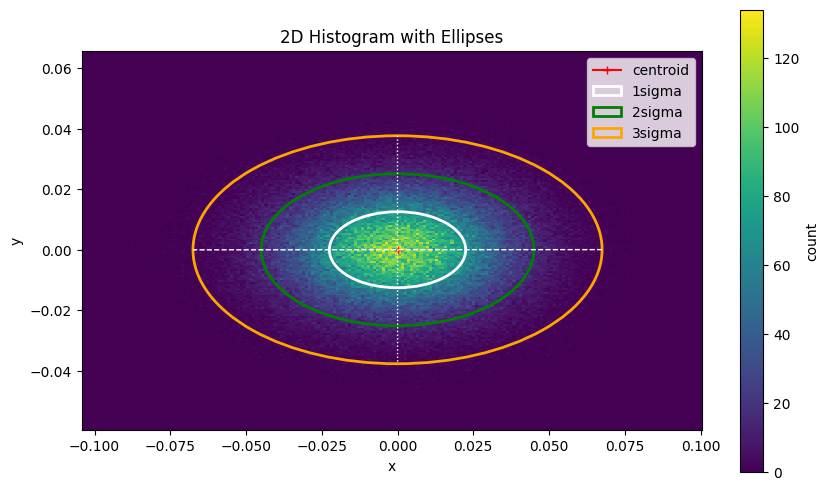

In [93]:
cax.dvf_B1.image.plot()